# Practice Lab: Regularization with Ridge, Lasso, and ElasticNet

We are tackling a common problem in Data Science: **Multicollinearity** (when your features are highly correlated with each other) and **Overfitting**. 

To solve this, we will use **Regularization**, which penalizes complex models. You will build and compare four models:
1. Standard Linear Regression (Base Model)
2. Ridge Regression ($L_2$ Penalty)
3. Lasso Regression ($L_1$ Penalty)
4. ElasticNet (Combination of $L_1$ and $L_2$)

### Abalone & The Business Problem
We will use the famous Abalone dataset to predict the age of an abalone (a highly valued marine snail) based on its physical measurements. 

**Why does predicting their age matter?**

Abalones are a premium seafood delicacy, making them vulnerable to overfishing. Strict regulations are in place to ensure abalones are only harvested after they reach a certain age, allowing them time to reproduce. Furthermore, aquaculture farms need to track age to optimize feeding and harvest times for profit. 

Currently, determining an abalone's age is a destructive, expensive, and tedious process: it requires cutting the shell, staining it, and counting the rings under a microscope. **Our goal is to build a Machine Learning model that can predict the age (number of rings) using simple, non-destructive measurements like weight and length.** If successful, we can save fisheries time and money!

**Data Dictionary:**
|Column| Definition |
|------|------------|
|`Sex`|: M (Male), F (Female), I (Infant)|
|`Length`|: Longest shell measurement (mm)|
|`Diameter`|: Perpendicular to length (mm)|
|`Height`|: With meat in shell (mm)|
|`Whole_weight`|: Whole abalone (grams)|
|`Shucked_weight`|: Weight of meat (grams)|
|`Viscera_weight`|: Gut weight after bleeding (grams)|
|`Shell_weight`|: After being dried (grams)|
|`Class` (Target)|: Number of rings. *Note: Age is roughly rings + 1.5 years.*|

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 1. Load the Data
We will fetch the Abalone dataset directly from OpenML.

In [2]:
# Fetch Abalone dataset (version 1)
abalone = fetch_openml(name="abalone", version=1, as_frame=True, parser='auto')
df = abalone.frame

# Rename the target column from 'Class' to 'Rings' for clarity
df = df.rename(columns={'Class_number_of_rings': 'Rings'})

# Display the first 5 rows
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 2. Exploratory Data Analysis (EDA)
Before modeling, let's understand our data. Regularization is especially useful when features are highly correlated. Let's prove that this dataset has high multicollinearity.

In [3]:
# TODO: Check for missing values in the dataframe
df.isnull().sum()


Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64

In [6]:
df.dtypes

Sex               category
Length             float64
Diameter           float64
Height             float64
Whole_weight       float64
Shucked_weight     float64
Viscera_weight     float64
Shell_weight       float64
Rings             category
dtype: object

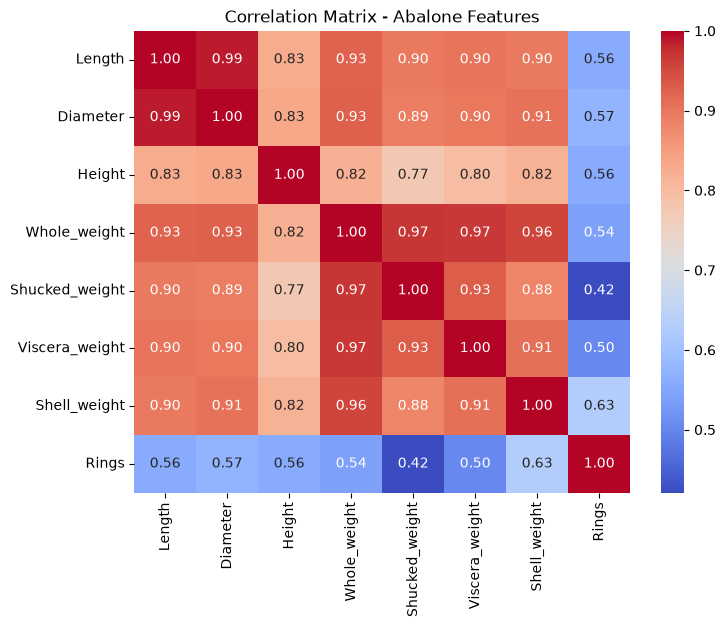

In [10]:
# TODO: Create a correlation matrix for the NUMERICAL features only.
# and NOTE down your observation!
# Hint: Drop the 'Sex' column temporarily or select only numeric columns.
# Optional but recommended: Plot this using sns.heatmap()
numeric_df = df.drop(columns=['Sex'])
corr_matrix = numeric_df.corr()
corr_matrix

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix - Abalone Features')
plt.show()

>Observation:
>
>The features show strong multicollinearity — Length and Diameter are almost perfectly correlated (0.99), and the weight-related features correlate at 0.88–0.97 with each other. This instability in Linear Regression coefficients is exactly why we need regularization.

## 3. Data Preprocessing
Machine Learning models need numbers, not text. We need to handle the categorical `Sex` column and split our data. 

**Crucial Note for Regularization:** You MUST scale your features when using Ridge, Lasso, or ElasticNet. Because regularization penalizes the size of the coefficients, features on larger scales (like thousands) will be penalized unfairly compared to features on smaller scales (like decimals) if they aren't standardized first.

In [13]:
df['Sex'].value_counts()

Sex
M    1528
I    1342
F    1307
Name: count, dtype: int64

In [14]:
# TODO: One-hot encode the 'Sex' column using pd.get_dummies() or One-hot Encoding. 
# Hint: Use drop_first=True to avoid the dummy variable trap.
df_encoded = pd.get_dummies(df, columns=['Sex'], drop_first=True , dtype=int)
df_encoded.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,0,1
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,0,1
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,0,0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,0,1
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,1,0


In [15]:
# TODO: Separate your features (X) and target (y)
X = df_encoded.drop(columns=['Rings'])
y = df_encoded['Rings']


In [16]:
# TODO: Perform a train_test_split. Use a test_size of 0.2 and random_state of 10.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [17]:
# TODO: Initialize the StandardScaler
scaler = StandardScaler()

# TODO: Fit the scaler on the training data AND transform X_train. 
X_train_scaled = scaler.fit_transform(X_train)

# TODO: Transform the test data (Do NOT fit the scaler on the test data!)
X_test_scaled = scaler.transform(X_test)

## 4. Don't Repeat Yourself (DRY): Evaluation Function
As good programmers, we want to avoid writing the same evaluation code four times. 

Write a function that takes in a fitted model, the training data, and the testing data, and prints out the $R^2$ and Root Mean Squared Error (RMSE) for BOTH the training and test sets. Comparing train vs. test metrics helps us spot overfitting!

*__Note__: You can add this to your go-to function toolbox!*

In [22]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Predicts and calculates R2 and RMSE for both train and test sets.
    Then prints the Train R2 and RMSE along with the Test R2 and RMSE
    """
    print(f"--- {model_name} Performance ---")
    
    # TODO: Generate predictions for both X_train and X_test
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # TODO: Calculate R2 for train and test
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # TODO: Calculate RMSE for train and test (Hint: mean_squared_error(..., squared=False))
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # TODO: Print the results clearly
    print(f"Train R2: {train_r2:.4f} | Train RMSE: {train_rmse:.4f}")
    print(f"Test  R2: {test_r2:.4f} | Test  RMSE: {test_rmse:.4f}")

## 5. Base Model: Standard Linear Regression
Let's see how a standard linear regression model handles this highly correlated data.

In [23]:
# TODO: Initialize and fit a standard Linear Regression model on the SCALED training data
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# TODO: Use your custom evaluate_model() function to check its performance
evaluate_model(lr_model, X_train_scaled, X_test_scaled, y_train, y_test, model_name="Linear Regression")

--- Linear Regression Performance ---
Train R2: 0.5349 | Train RMSE: 2.2113
Test  R2: 0.5497 | Test  RMSE: 2.1116


## 6. Regularization Models
Now, let's apply penalties to our model to handle the multicollinearity.

Instead of guessing the penalty term (`alpha`), we will use Scikit-Learn's built-in Cross-Validation models (`RidgeCV`, `LassoCV`, `ElasticNetCV`). These models automatically try a list of different alphas and select the one that performs best!

### RIDGE REGRESSION (L2 Penalty)

In [24]:
# We provide a list of alphas to test (from very small to very large)
alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]

# TODO: Initialize RidgeCV with the alphas_to_test, cv=5, random_state=10 and fit it to the training data
ridge_model = RidgeCV(alphas=alphas_to_test, cv=5)
ridge_model.fit(X_train_scaled, y_train)

# TODO: Use evaluate_model() to check performance
evaluate_model(ridge_model, X_train_scaled, X_test_scaled, y_train, y_test, model_name="Ridge Regression")

# TODO: Print the best alpha found by RidgeCV (Hint: look up the .alpha_ attribute)
print(f"Best alpha: {ridge_model.alpha_}")

--- Ridge Regression Performance ---
Train R2: 0.5349 | Train RMSE: 2.2114
Test  R2: 0.5497 | Test  RMSE: 2.1118
Best alpha: 1.0


### LASSO REGRESSION (L1 Penalty)

__Note__: You can provide a custom list to `LassoCV` and `ElasticNetCV` if you want to, but it is generally best practice to leave it blank and let Scikit-Learn automatically calculate the optimal path for you.

In [26]:
# TODO: Initialize LassoCV (you can let it choose alphas automatically by not passing any), cv=5, random_state=10 
# and fit it to the training data
lasso_model= LassoCV(cv=5, random_state=10)
lasso_model.fit(X_train_scaled, y_train)

# TODO: Use evaluate_model() to check performance
evaluate_model(lasso_model, X_train_scaled, X_test_scaled, y_train, y_test, model_name="Lasso Regression")

# TODO: Print the best alpha found by LassoCV
print(f"Best alpha: {lasso_model.alpha_}")

--- Lasso Regression Performance ---
Train R2: 0.5347 | Train RMSE: 2.2118
Test  R2: 0.5493 | Test  RMSE: 2.1126
Best alpha: 0.003102557702171799


### ELASTICNET REGRESSION (L1 + L2 Penalty)

In [27]:
# TODO: Initialize ElasticNetCV with cv=5, random_state=10 and fit it to the training data
elasticnet_model = ElasticNetCV(cv=5, random_state=10)
elasticnet_model.fit(X_train_scaled, y_train)

# TODO: Use evaluate_model() to check performance
evaluate_model(elasticnet_model, X_train_scaled, X_test_scaled, y_train, y_test, model_name="ElasticNet Regression")

# TODO: Print the best alpha found by ElasticNetCV
print(f"Best alpha: {elasticnet_model.alpha_}")

--- ElasticNet Regression Performance ---
Train R2: 0.5335 | Train RMSE: 2.2148
Test  R2: 0.5480 | Test  RMSE: 2.1156
Best alpha: 0.004082551587352136


## 7. Feature Selection with Lasso
One of the superpower traits of Lasso ($L_1$ regularization) is that it can shrink the coefficients of useless or highly correlated features down to **exactly zero**. This acts as automatic feature selection.

Let's look at the coefficients of our models to see this in action.

In [28]:
# Provided Code: Run this cell to compare coefficients!
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Linear_Coef': lr_model.coef_,       # Update 'lr_model' if you named your Linear Regression variable differently
    'Ridge_Coef': ridge_model.coef_,     # Update 'ridge_model' if needed
    'Lasso_Coef': lasso_model.coef_,      # Update 'lasso_model' if needed
    'ElasticNet_Coef': elasticnet_model.coef_
})

# Display the coefficients
coef_df.round(3)

,Feature,Linear_Coef,Ridge_Coef,Lasso_Coef,ElasticNet_Coef
0,Length,0.020,0.025,0.000,0.029
1,Diameter,0.984,0.976,0.981,0.942
2,Height,0.440,0.441,0.437,0.442
3,Whole_weight,4.385,4.202,3.955,3.161
4,Shucked_weight,-4.370,-4.283,-4.168,-3.776
5,Viscera_weight,-1.125,-1.083,-0.987,-0.817
6,Shell_weight,1.254,1.315,1.382,1.640
7,Sex_I,-0.388,-0.390,-0.389,-0.396
8,Sex_M,0.012,0.012,0.008,0.006


__Q1. Which feature(s) did Lasso completely drop (set to 0)?__ 

__Answer:__  Lasso set 'Length' to exactly 0, since it's almost perfectly correlated with Diameter (0.99) and therefore redundant.



__Q2. How does ElasticNet compare to Lasso and Ridge here?__

__Answer:__  ElasticNet behaves like a mix of both — it shrinks large coefficients similar to Lasso (e.g., Whole_weight drops to 3.161) but, unlike Lasso, doesn't set any feature to exactly zero, keeping Ridge's "no elimination" behavior.




## 8. Communicating Results to Stakeholders

**Scenario:** 
Imagine you are presenting these findings to the manager of a seafood fishery. They have no background in data science or math. They want to know if they can trust this model to replace the manual, time-consuming process of cutting abalone shells and counting rings under a microscope. 

**How to phrase your answer:**
When speaking to stakeholders, avoid throwing raw math at them. Translate the metrics into real-world impact. 

*Example using a Real Estate Model:*
*   ❌ **Bad:** "The model has an RMSE of 25000 and an $R^2$ of 0.85."
*   ✅ **Good:** "Our model is highly accurate, capturing about 85% of the factors that drive house prices. When it makes a prediction, it is typically off by about $25,000 on average."

**Your Task:**
Double-click this text cell. Based on your best model's RMSE and $R^2$ scores, write a 3-4 sentence explanation answering the fishery manager's question. Be honest about whether the model is accurate enough to replace humans entirely, or if it should just be used as an estimation tool.
> Our model estimates abalone age fairly well without cutting the shell, though its predictions are typically off by about 2 rings, and it explains around 55% of what drives age differences. It's a fast, cheap screening tool, but not accurate enough to fully replace manual counting for cases where precision matters.

# Now it’s your turn!
1. Derive at least one new feature that adds value to the dataset.
2. Apply a feature selection technique to eliminate uninformative variables.
3. Document your reasoning in clean Markdown cells as you go!

In [29]:
# Markdown: We create a new feature 'Shell_ratio' representing the proportion of 
# shell weight relative to total weight. This may capture maturity/composition 
# patterns that raw weights alone don't reveal.

df_encoded['Shell_ratio'] = df_encoded['Shell_weight'] / df_encoded['Whole_weight']
df_encoded[['Shell_weight', 'Whole_weight', 'Shell_ratio']].head()

,Shell_weight,Whole_weight,Shell_ratio
0,0.150,0.5140,0.291829
1,0.070,0.2255,0.310421
2,0.210,0.6770,0.310192
3,0.155,0.5160,0.300388
4,0.055,0.2050,0.268293


In [35]:
X_new = df_encoded.drop(columns=['Rings'])
y_new = df_encoded['Rings']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=10
)

In [36]:
scaler_new = StandardScaler()
X_train_new_scaled = scaler_new.fit_transform(X_train_new)
X_test_new_scaled = scaler_new.transform(X_test_new)

In [32]:
lasso_new = LassoCV(cv=5, random_state=10)
lasso_new.fit(X_train_new_scaled, y_train_new)

evaluate_model(lasso_new, X_train_new_scaled, X_test_new_scaled, y_train_new, y_test_new, model_name="Lasso with Shell_ratio")

print(f"Best alpha: {lasso_new.alpha_}")

--- Lasso with Shell_ratio Performance ---
Train R2: 0.5346 | Train RMSE: 2.2120
Test  R2: 0.5495 | Test  RMSE: 2.1122
Best alpha: 0.005813626677759198


In [33]:
coef_new_df = pd.DataFrame({
    'Feature': X_train_new.columns,
    'Lasso_Coef': lasso_new.coef_
})
coef_new_df.round(3)

,Feature,Lasso_Coef
0,Length,0.000
1,Diameter,0.976
2,Height,0.440
3,Whole_weight,3.793
4,Shucked_weight,-4.025
5,Viscera_weight,-0.884
6,Shell_weight,1.316
7,Sex_I,-0.389
8,Sex_M,0.004
9,Shell_ratio,0.069


In [37]:
# Feature Selection: Drop 'Length' since Lasso consistently shrinks it to 0,
# confirming it's redundant given its near-perfect correlation with Diameter.

X_selected = X_new.drop(columns=['Length'])

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y_new, test_size=0.2, random_state=10
)

scaler_sel = StandardScaler()
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)
X_test_sel_scaled = scaler_sel.transform(X_test_sel)

final_model = LassoCV(cv=5, random_state=10)
final_model.fit(X_train_sel_scaled, y_train_sel)

evaluate_model(final_model, X_train_sel_scaled, X_test_sel_scaled, y_train_sel, y_test_sel, model_name="Final Model (Length removed)")

--- Final Model (Length removed) Performance ---
Train R2: 0.5347 | Train RMSE: 2.2117
Test  R2: 0.5496 | Test  RMSE: 2.1118


**Feature Engineering:**
We added 'Shell_ratio' (Shell_weight / Whole_weight) to capture the shell's proportion of total body weight. It had minimal impact (Lasso coefficient of only 0.069), suggesting it doesn't add meaningful new information beyond the existing weight features.

**Feature Selection:**
Lasso consistently shrinks 'Length' to exactly 0 across all runs, confirming it's redundant due to its near-perfect correlation (0.99) with Diameter. After removing 'Length' from the dataset, the model's performance remained virtually unchanged (Test R² = 0.5496 vs 0.5493 before), confirming that this feature carried no unique predictive value.